# Titanic Survival Analysis

*Performed data cleaning, missing value handling, outlier detection, exploratory data analysis, and visualization on the Titanic dataset using Pandas, Matplotlib, and Seaborn.*

IMPORTING LIBRARIES

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
df=pd.read_csv(r"C:\Users\muham\Downloads\Titanic-Dataset.csv")

Top 5 Rows Of Dataset

In [101]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [102]:
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [103]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [104]:
df.shape

(891, 12)

In [105]:
df.duplicated().sum()

np.int64(0)

In [106]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [107]:
df=df.drop(['PassengerId','Name','Ticket','Cabin'],axis=1)

In [108]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


# DATA PREPROCESSING

## Missing Value Handling:

In [109]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [110]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

<Axes: >

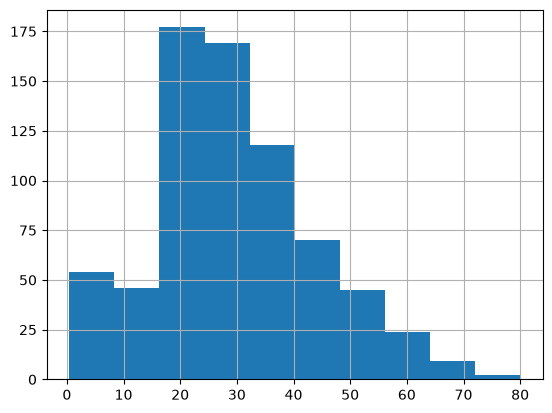

In [111]:
df['Age'].hist()

In [112]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [113]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [114]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


## Outlier Handling

<Axes: >

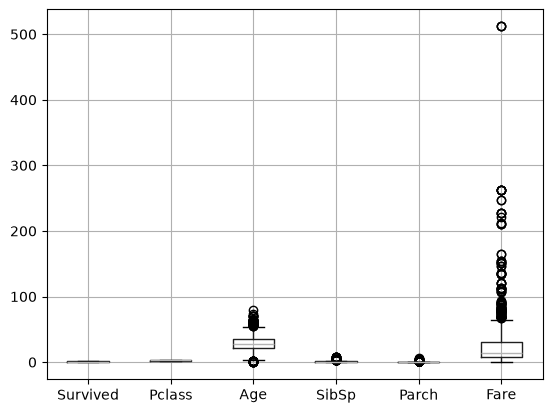

In [115]:
df.boxplot()

In [116]:
#CLIPPING METHOD
for i in ["Fare","Age","SibSp","Parch"]:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df[i]=df[i].clip(lower,upper)

<Axes: >

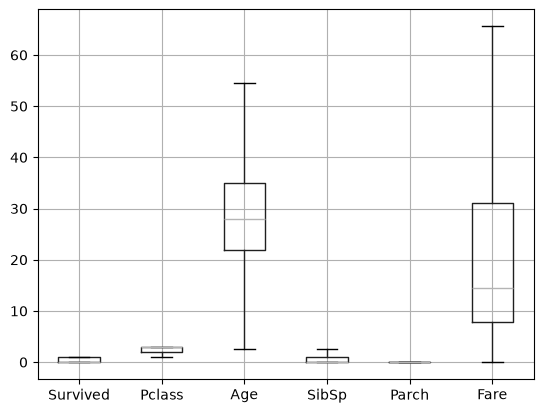

In [117]:
df.boxplot()

## Feature Engineering

In [118]:
df["familycount"]=df["SibSp"]+df["Parch"]

In [119]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,familycount
0,0,3,male,22.0,1.0,0,7.2500,S,1.0
1,1,1,female,38.0,1.0,0,65.6344,C,1.0
2,1,3,female,26.0,0.0,0,7.9250,S,0.0
3,1,1,female,35.0,1.0,0,53.1000,S,1.0
4,0,3,male,35.0,0.0,0,8.0500,S,0.0
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0.0,0,13.0000,S,0.0
887,1,1,female,19.0,0.0,0,30.0000,S,0.0
888,0,3,female,28.0,1.0,0,23.4500,S,1.0
889,1,1,male,26.0,0.0,0,30.0000,C,0.0


In [120]:
df=df.drop(["Parch","SibSp"],axis=1)

In [121]:
df

,Survived,Pclass,Sex,Age,Fare,Embarked,familycount
0,0,3,male,22.0,7.2500,S,1.0
1,1,1,female,38.0,65.6344,C,1.0
2,1,3,female,26.0,7.9250,S,0.0
3,1,1,female,35.0,53.1000,S,1.0
4,0,3,male,35.0,8.0500,S,0.0
...,...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,S,0.0
887,1,1,female,19.0,30.0000,S,0.0
888,0,3,female,28.0,23.4500,S,1.0
889,1,1,male,26.0,30.0000,C,0.0


In [122]:
sum_fare=df.groupby("Sex")["Fare"].mean()
sum_fare

Sex
female    30.566906
male      20.498617
Name: Fare, dtype: float64

So Female passengers paid more than that of Male passengers.

In [123]:
df

,Survived,Pclass,Sex,Age,Fare,Embarked,familycount
0,0,3,male,22.0,7.2500,S,1.0
1,1,1,female,38.0,65.6344,C,1.0
2,1,3,female,26.0,7.9250,S,0.0
3,1,1,female,35.0,53.1000,S,1.0
4,0,3,male,35.0,8.0500,S,0.0
...,...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,S,0.0
887,1,1,female,19.0,30.0000,S,0.0
888,0,3,female,28.0,23.4500,S,1.0
889,1,1,male,26.0,30.0000,C,0.0


## Univariate Analysis

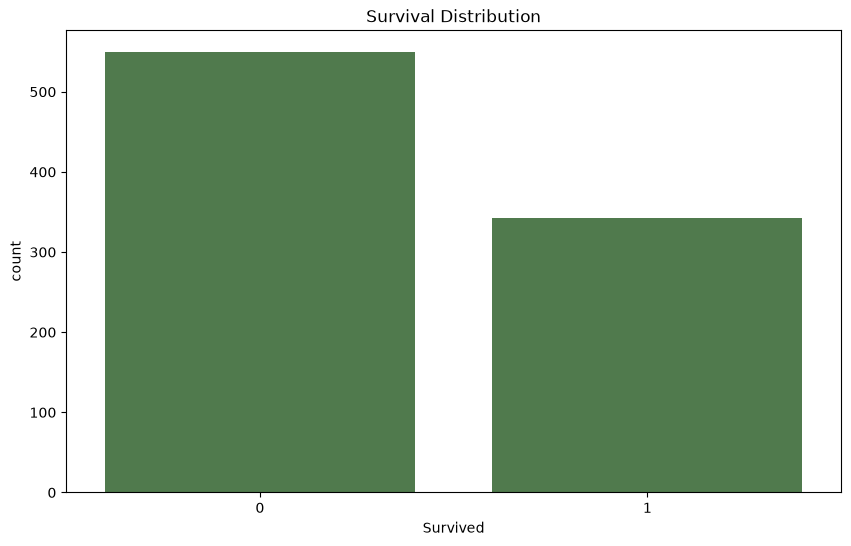

In [124]:
plt.figure(figsize=(10,6))
sns.countplot(x="Survived",data=df,color="#4A8146")
plt.title("Survival Distribution")
plt.show()

More passengers died than survived in the Titanic Disaster,showing that survival was not common among the passengers on board.

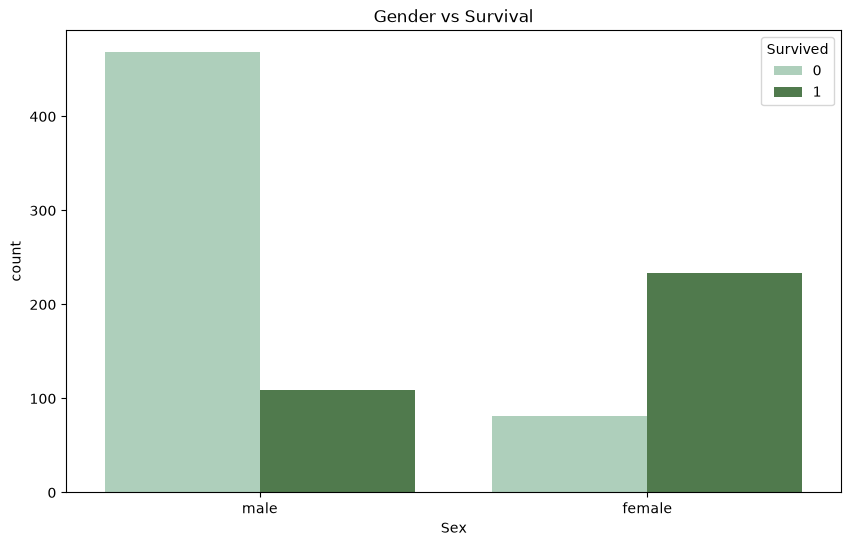

In [131]:
plt.figure(figsize=(10,6))
sns.countplot(x="Sex",hue="Survived",data=df,palette=["#A8D5BA","#4A8146"])
plt.title("Gender vs Survival")
plt.show()

Female passengers were more likely to survive than male passengers,indicating a strong relationship between gender and survival.

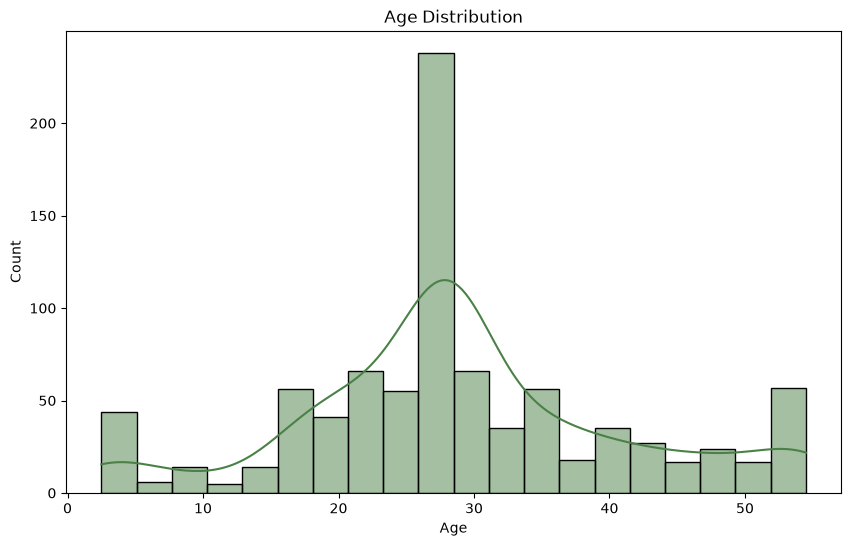

In [126]:
plt.figure(figsize=(10,6))
sns.histplot(df["Age"],kde=True,color="#4A8146")
plt.title("Age Distribution")
plt.show()

Most Titanic passengers were between 20-40 years old,while children and elderly passengers were fewer in number.The age distribution is concentrated around young and middle-aged adults.

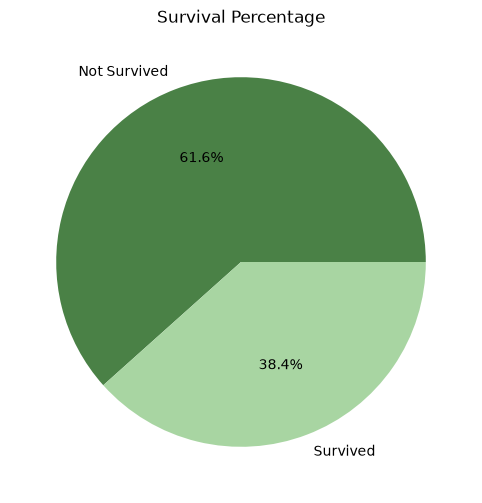

In [ ]:
plt.figure(figsize=(10,6))
colors = ["#4A8146", "#A8D5A2"]
df["Survived"].value_counts().plot(kind="pie",autopct="%1.1f%%",labels=["Not Survived","Survived"],colors=colors)
plt.title("Survival Percentage")
plt.show()

Most passengers (61.6) did not survive the Titanic disaster,while 38.4% survived. 

## Bivariate Analysis

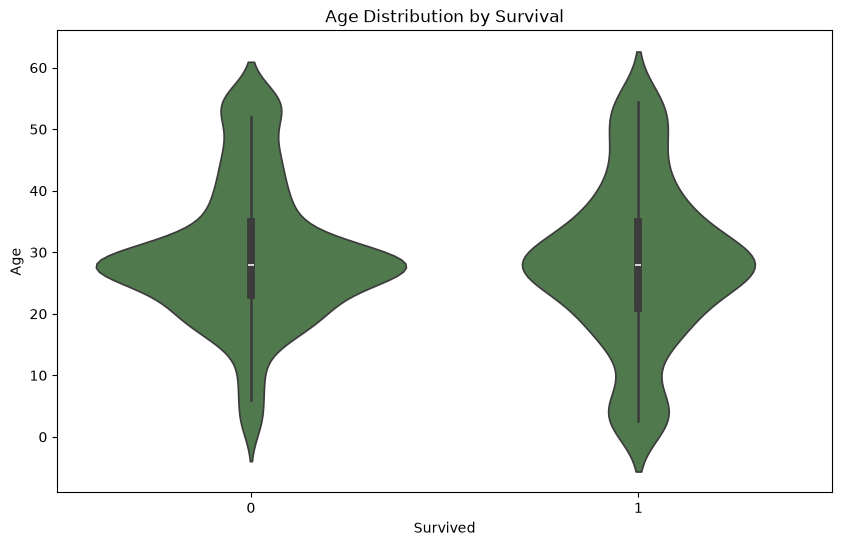

In [128]:
plt.figure(figsize=(10,6))
sns.violinplot(x="Survived",y="Age",data=df,color="#4A8146")
plt.title("Age Distribution by Survival")
plt.show()

Most survivors and non-survivors were aged between 20-40 years,indicating that the majority of Titanic passengers belonged to this age group.

## Multivariate Analysis

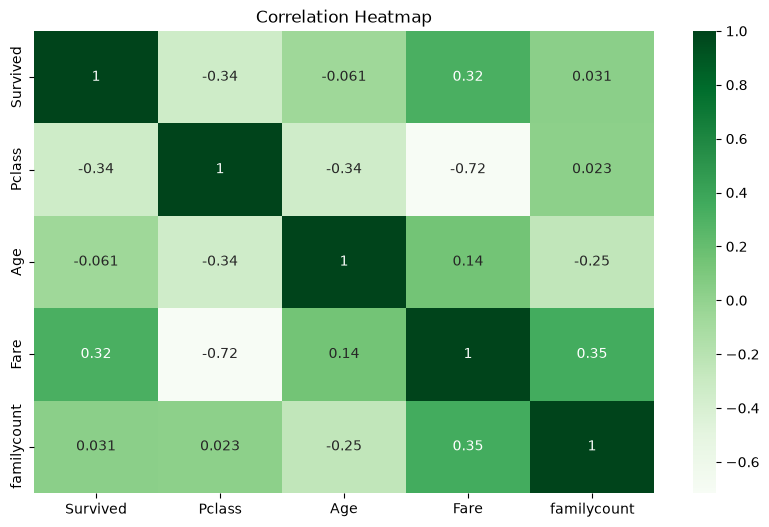

In [129]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Greens")
plt.title("Correlation Heatmap")
plt.show()

Survived vs Fare = 0.32 → Higher fare → Higher survival chance.

Survived vs Pclass = -0.34 → Lower class number (1st class) → Better survival.

Survived vs Age = -0.06 → Almost no relationship.

Strongest correlation visible: Pclass and Fare (-0.72).